In [1]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader

In [2]:
!ls -l

total 8
drwxrwxr-x 4 harhaleval harhaleval 4096 Jun  6 13:55 rcnn-family
drwxrwxr-x 6 harhaleval harhaleval 4096 Jun  5 18:19 yolo


In [3]:
os.chdir('rcnn-family')

In [4]:
def open_image(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

In [5]:
FOLDER = 'fruits_dataset'
TRAIN_FOLDER = os.path.join(FOLDER, 'train')
TEST_FOLDER = os.path.join(FOLDER, 'test')

In [366]:
train_files = os.listdir(TRAIN_FOLDER)
test_files = os.listdir(TEST_FOLDER)

In [7]:
a = []
for file in train_files:
    if file.endswith('.jpg'):
        a.append(cv2.imread(os.path.join(TRAIN_FOLDER, file)).shape[-1] > 3)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


shape - (657, 800, 3)


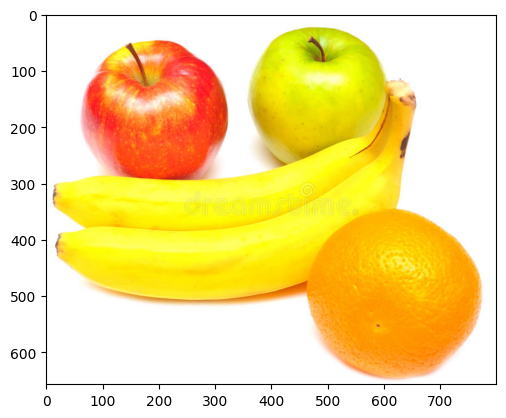

In [8]:
rand_img = random.choice(train_files).split('.')[0] + '.jpg'
img = open_image(os.path.join(TRAIN_FOLDER, rand_img))

print(f'shape - {img.shape}')
plt.imshow(img)
plt.show()

# Classification task

In [9]:
from torchvision.models import resnet18, ResNet18_Weights 

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [173]:
fe = resnet18(weights=ResNet18_Weights).to(device)

In [174]:
fe

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [175]:
fe_trans = ResNet18_Weights.IMAGENET1K_V1.transforms()
fe_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [176]:
res = fe(fe_trans(Image.fromarray(img)).unsqueeze(0).to(device))

In [177]:
res.shape

torch.Size([1, 1000])

In [178]:
in_ftr = fe.fc.in_features
fe.fc = nn.Linear(in_ftr, 3).to(device)

In [179]:
classes = ['apple', 'banana', 'orange']
class ClfDataset(torch.utils.data.Dataset):
    def __init__(self, folder, mode='train'):
        self.mode = mode
        files = os.listdir(folder)
        images = [ file for file in files if file.endswith('.jpg') and not file.startswith('mixed') ]
        self.labels = [ classes.index(image.split('_')[0]) for image in images ]
        self.images = [ Image.open(os.path.join(folder, image)).convert('RGB') for image in images ]
        self.trans = T.Compose(
            [
                T.RandomHorizontalFlip(p=0.5),
                T.RandomVerticalFlip(p=0.5),
                T.RandomRotation(degrees=30),
                T.RandomResizedCrop(size=224, scale=(0.6, 1.0))
            ]
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = fe_trans(self.trans(self.images[idx])) if self.mode == 'train' else fe_trans(self.images[idx])
        return fe_trans(self.images[idx]), self.labels[idx]

In [180]:
train_clf_dataset = ClfDataset(TRAIN_FOLDER)
test_clf_dataset = ClfDataset(TEST_FOLDER)

In [181]:
len(train_clf_dataset), len(test_clf_dataset)

(220, 55)

In [182]:
batch_size=1024
train_clf_loader = DataLoader(train_clf_dataset, batch_size=1024, shuffle=True, pin_memory=True, num_workers=4)
test_clf_loader = DataLoader(test_clf_dataset, batch_size=1024, pin_memory=True, num_workers=4)

In [183]:
def learning_loop(model, train_data_loader, test_data_loader, criterion, opt, epochs, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        
        
        model.train()
        train_loss = 0
        train_acc = 0
        num_samples = 0
        with tqdm(total=len(train_data_loader), desc="Train", leave=False) as pbar:
            for idx, (X_batch, y_batch) in enumerate(train_data_loader):
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
    
                opt.zero_grad()
                loss.backward()
                opt.step()
    
                train_loss += loss.item()
                train_acc += (torch.argmax(pred, dim=-1) == y_batch).sum().item()
                num_samples += len(X_batch)
                pbar.update(1)
        train_loss /= num_samples
        train_acc /= num_samples
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
    
    
        model.eval()
        val_loss = 0
        val_acc = 0
        num_samples = 0
        with tqdm(total=len(test_data_loader), desc="Validation", leave=False) as pbar:
            with torch.no_grad():
                for idx, (X_batch, y_batch) in enumerate(test_data_loader):
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)
                
                    val_loss += loss.item()
                    val_acc += (torch.argmax(pred, dim=-1) == y_batch).sum().item()
                    num_samples += len(X_batch)
                    pbar.update(1)
        val_loss /= num_samples
        val_acc /= num_samples
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        history['lr'].append(opt.param_groups[0]['lr'])
        print(f"Training Loss: {history['train_loss'][-1]:.4f}, Training Accuracy: {history['train_acc'][-1]:.4f}")
        print(f"Testing Loss: {history['val_loss'][-1]:.4f}, Testing Accuracy: {history['val_acc'][-1]:.4f}")
        print(f"Learning Rate: {history['lr'][-1]:.2e}")
        print()

        if scheduler is not None:
            try:
                scheduler.step()
            except:
                scheduler.step(history['train_loss'])
            

    return history

In [184]:
lr = 1e-4
epochs = 20

criterion = nn.CrossEntropyLoss()
opt = torch.optim.AdamW(fe.parameters(), lr=lr, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.LinearLR(opt, 0.1, 1, 15)
# scheduler = None

In [185]:
history = learning_loop(fe, train_clf_loader, test_clf_loader, criterion, opt, epochs=epochs, scheduler=scheduler)

Epoch 1/20


Train:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss: 0.0054, Training Accuracy: 0.3727
Testing Loss: 0.0191, Testing Accuracy: 0.3818
Learning Rate: 1.00e-05

Epoch 2/20


Train:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss: 0.0000, Training Accuracy: 1.0000
Testing Loss: 0.0003, Testing Accuracy: 1.0000
Learning Rate: 1.00e-04

Epoch 20/20


Train:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss: 0.0000, Training Accuracy: 1.0000
Testing Loss: 0.0002, Testing Accuracy: 1.0000
Learning Rate: 1.00e-04



# Detection task

In [186]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img)
ss.switchToSelectiveSearchFast()  
# ss.switchToSelectiveSearchQuality() # Slow but more accurate
rects = ss.process()

In [341]:
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    boxes = []
    for obj in root.findall('object'):
        class_name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        w = xmax - xmin
        h = ymax - ymin
        boxes.append((xmin, ymin, w, h))
    
    return boxes

xml_path = "fruits_dataset/train/apple_11.xml"
gt_boxes = parse_xml(xml_path)

for (xmin, ymin, w, h) in gt_boxes:
    print(f"BBox: ({xmin}, {ymin}, {w}, {h})")

BBox: (213, 33, 246, 225)
BBox: (1, 30, 187, 250)
BBox: (116, 5, 221, 215)


1188


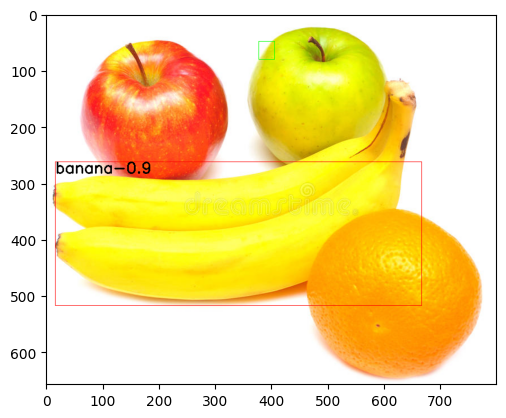

In [342]:
copy = img.copy()
for i, rect in enumerate(rects[9:10]):
    x, y, w, h = rect
    cv2.rectangle(copy, (x, y), (x+w, y+h), (0, 255, 0), 1)

bbs = parse_xml(os.path.join(TRAIN_FOLDER, rand_img.split('.')[0] + '.xml'))

for bb in bbs[2:3]:
    x, y, w, h = bb
    cv2.rectangle(copy, (x, y), (x+w, y+h), (255, 0, 0), 1)
    cv2.putText(copy, "banana-0.9", (x, y+20), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)
 
print(len(rects))
plt.imshow(copy)
plt.show()

In [343]:
def iou(bb, gt):
    bb_x1, bb_y1, bb_x2, bb_y2 = bb[0], bb[1], bb[0] + bb[2], bb[1] + bb[3]
    gt_x1, gt_y1, gt_x2, gt_y2 = gt[0], gt[1], gt[0] + gt[2], gt[1] + gt[3]
    
    mn_x, mx_x = max(bb_x1, gt_x1), min(bb_x2, gt_x2)
    mn_y, mx_y = max(bb_y1, gt_y1), min(bb_y2, gt_y2)

    # print(f'{mn_x=}; {mx_x=}; {mn_y=}; {mx_y=}')
    intersection = max(0, mx_x - mn_x) * max(0, mx_y - mn_y)
    union = bb[2] * bb[3] + gt[2] * gt[3] - intersection

    # print(intersection, union)
    assert intersection >= 0 and union >= 0, f'{bb}; {gt}'
    return intersection / union

In [344]:
from copy import deepcopy
reg_fe = deepcopy(fe)
in_ftr = fe.fc.in_features
reg_fe.fc = nn.Linear(in_ftr, 4).to(device)

In [345]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [346]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

class RegressionDataset(torch.utils.data.Dataset):
    P=16
    def __init__(self, folder):
        files = os.listdir(folder)
        files = np.unique([file.split('.')[0] for file in files])
        self.bbs = []
        self.gts = []
        self.ys = []
        self.images = []
        for i, file in enumerate(tqdm(files)):
            img = open_image(os.path.join(folder, file + '.jpg'))
            ss.setBaseImage(img)
            ss.switchToSelectiveSearchFast()
            cur_bbs = ss.process()[:1000]
            cur_gts = parse_xml(os.path.join(folder, file + '.xml'))

            for cur_bb in cur_bbs:
                cands = []
                for cur_gt in cur_gts:
                    val = iou(cur_bb, cur_gt)
                    if val > 0.6:
                        cands.append((val, cur_gt))
                if cands:
                    cands.sort(reverse=True)
                    self.bbs.append(cur_bb)
                    cur_gt = cands[0][-1]
                    self.gts.append(cur_gt)
                    cur_y = [
                        (cur_gt[0] - cur_bb[0]) / cur_bb[2],
                        (cur_gt[1] - cur_bb[1]) / cur_bb[3],
                        np.log(cur_gt[2]/cur_bb[2]),
                        np.log(cur_gt[3]/cur_bb[3])
                    ]
                    bb_x1, bb_y1, bb_w, bb_h = \
                    max(cur_bb[0]-self.P, 0), max(cur_bb[1]-self.P, 0), cur_bb[2] + 2 * self.P, cur_bb[3] + 2 * self.P
                    self.ys.append(cur_y)
                    self.images.append(fe_trans(
                        Image.fromarray(img[bb_y1:bb_y1+bb_h, bb_x1:bb_x1+bb_w])
                    ))

    def __len__(self):
        return len(self.bbs)

    def __getitem__(self, idx):
        return self.images[idx], torch.tensor(self.ys[idx], dtype=torch.float32)
                    

In [223]:
train_reg_dataset = RegressionDataset(TRAIN_FOLDER)
test_reg_dataset = RegressionDataset(TEST_FOLDER)

  0%|          | 0/240 [00:00<?, ?it/s]

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


  0%|          | 0/60 [00:00<?, ?it/s]

libpng warning: iCCP: known incorrect sRGB profile


In [347]:
batch_size=256
train_reg_loader = DataLoader(train_reg_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
test_reg_loader = DataLoader(test_reg_dataset, batch_size=batch_size, pin_memory=True, num_workers=4)

In [348]:
def non_max_supression(bbs, scores, threshold=0.5):
    final_bbs = sorted(zip(bbs, scores), key=lambda x: x[1].values.item(), reverse=True)
    res_bbs = []
    for bbs, score in final_bbs:
        for comp, _ in res_bbs:
            if iou(bbs, comp) > threshold:
                break
        else:
            res_bbs.append((bbs, score))
    return res_bbs

In [352]:
def learning_loop(model, train_data_loader, test_data_loader, criterion, opt, epochs, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    # grads = {}
    for epoch in range(1, epochs+1):
        print(f"Epoch {epoch}/{epochs}")
        
        model.train()
        train_loss = 0
        with tqdm(total=len(train_data_loader), desc="Train", leave=False) as pbar:
            for idx, (X_batch, y_batch) in enumerate(train_data_loader):
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
    
                opt.zero_grad()
                loss.backward()
                opt.step()
    
                train_loss += loss.item()
                pbar.update(1)
        history['train_loss'].append(train_loss / len(train_data_loader))
        for name, param in model.named_parameters():
            if param.requires_grad:
                grads.setdefault(name, []).append(torch.norm(param))
    
    
        model.eval()
        val_loss = 0
        with tqdm(total=len(test_data_loader), desc="Validation", leave=False) as pbar:
            with torch.no_grad():
                for idx, (X_batch, y_batch) in enumerate(test_data_loader):
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    pred = model(X_batch)
                    loss = criterion(pred, y_batch)
                
                    val_loss += loss.item()
                    pbar.update(1)
        history['val_loss'].append(val_loss / len(test_data_loader))

        history['lr'].append(opt.param_groups[0]['lr'])
        print(f"Training Loss: {history['train_loss'][-1]:.7f}")
        print(f"Testing Loss: {history['val_loss'][-1]:.7f}")
        print(f"Learning Rate: {history['lr'][-1]:.2e}")
        print()

        if scheduler is not None:
            try:
                scheduler.step()
            except:
                scheduler.step(history['train_loss'])

        if epoch % 10 == 0:
            imgs = []
            P = RegressionDataset.P
            imgs_per_folder = 2
            folders = [TRAIN_FOLDER, TEST_FOLDER]
            for folder in folders:
                rand_pathes = np.random.choice(os.listdir(folder), size=imgs_per_folder, replace=False)
                for rand_path in rand_pathes:
                    rand_path = rand_path.split('.')[0]
                    img = open_image(os.path.join(folder, rand_path + '.jpg'))
                    ss.setBaseImage(img)
                    ss.switchToSelectiveSearchFast()
                    cur_bbs = ss.process()[:1000]
                    cur_gts = parse_xml(os.path.join(folder, rand_path + '.xml'))
                    final_bbs = []
                    for cur_bb in cur_bbs:
                        for cur_gt in cur_gts:
                            val = iou(cur_bb, cur_gt)
                            if val > 0.6:
                                bb_x1, bb_y1, bb_w, bb_h = \
                                max(cur_bb[0]-P, 0), max(cur_bb[1]-P, 0), cur_bb[2] + 2*P, cur_bb[3] + 2*P
                                mx_info = F.softmax(fe(
                                    fe_trans(
                                        Image.fromarray(img[bb_y1:bb_y1+bb_h, bb_x1:bb_x1+bb_w])
                                    ).unsqueeze(0).to(device)), dim=-1
                                ).max(dim=-1)
                                final_bbs.append((cur_bb, mx_info))
                    
                    final_bbs = non_max_supression(*zip(*final_bbs))
                    for i, (bbs, mx_info) in enumerate(final_bbs):
                        x, y, w, h = bbs
                        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 0), 1)
                        label = classes[mx_info.indices.item()]
                        score = mx_info.values.item()
                        cv2.putText(img, f"{label}-{score:.3f}", (x, y+20), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)
                    imgs.append(img)
            plt.subplots(len(folders), imgs_per_folder, figsize=(10, 5))
            for i, img in enumerate(imgs, 1):
                plt.subplot(len(folders), imgs_per_folder, i)
                plt.imshow(img)
                plt.axis('off')
            plt.show()
            
                
                

    return history#, grads

In [353]:
lr = 5e-4
epochs = 20

criterion = nn.MSELoss()
opt = torch.optim.AdamW(reg_fe.parameters(), lr=lr, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.LinearLR(opt, 0.1, 1, 15)
# scheduler = None

Epoch 1/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training Loss: 0.0855065
Testing Loss: 0.0637461
Learning Rate: 5.00e-05

Epoch 2/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training Loss: 0.0031337
Testing Loss: 0.0234159
Learning Rate: 2.90e-04

Epoch 10/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training Loss: 0.0029329
Testing Loss: 0.0221858
Learning Rate: 3.20e-04



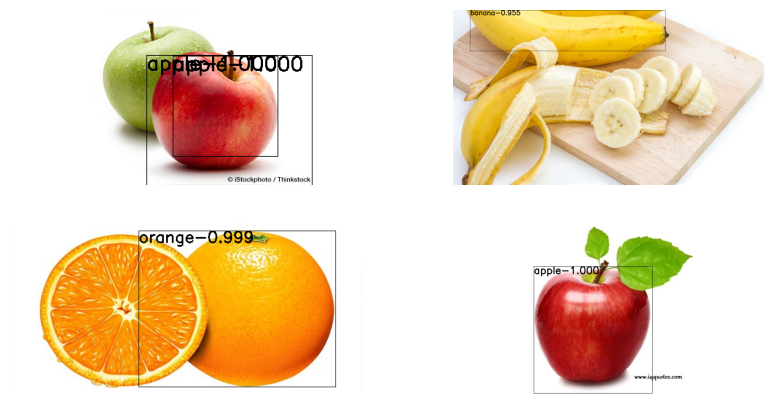

Epoch 11/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training Loss: 0.0026976
Testing Loss: 0.0211730
Learning Rate: 3.50e-04

Epoch 12/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

...

Training Loss: 0.0013182
Testing Loss: 0.0143795
Learning Rate: 5.00e-04

Epoch 20/20


Train:   0%|          | 0/25 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Training Loss: 0.0010936
Testing Loss: 0.0139375
Learning Rate: 5.00e-04



libpng warning: iCCP: known incorrect sRGB profile


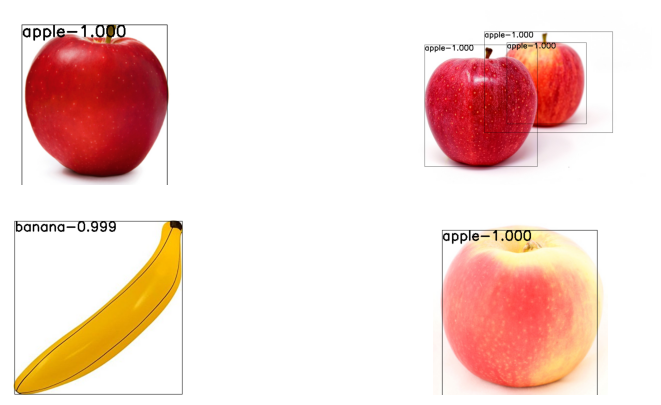

In [354]:
history = learning_loop(reg_fe, train_reg_loader, test_reg_loader, criterion, opt, epochs=epochs, scheduler=scheduler)

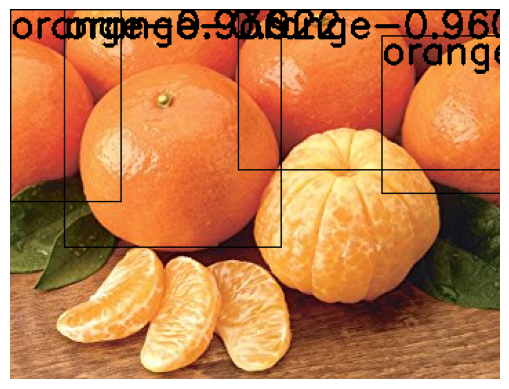

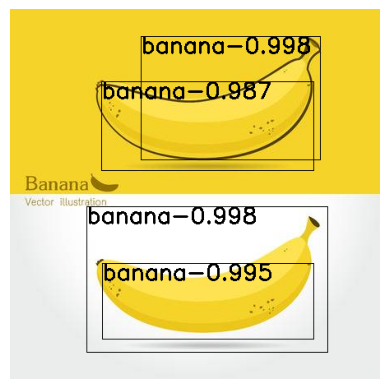

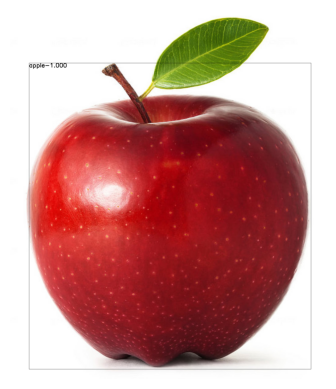

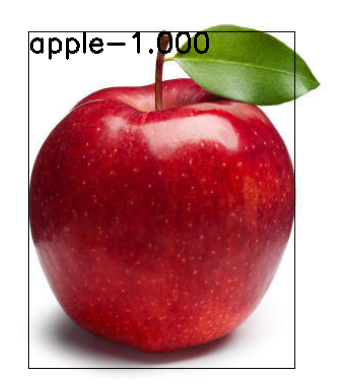

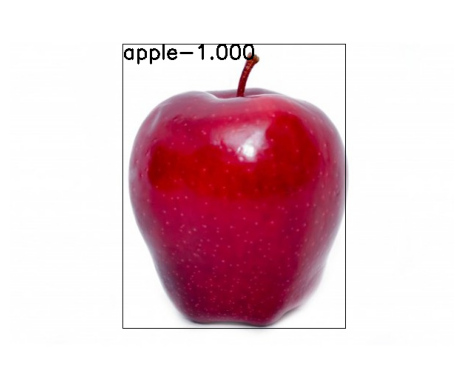

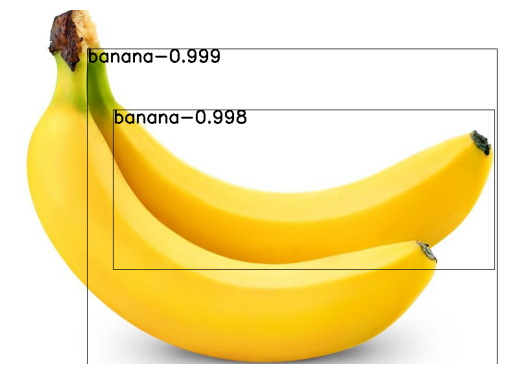

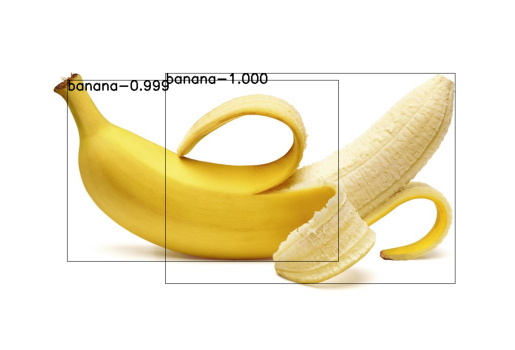

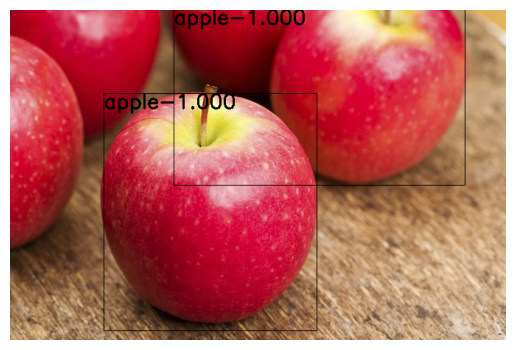

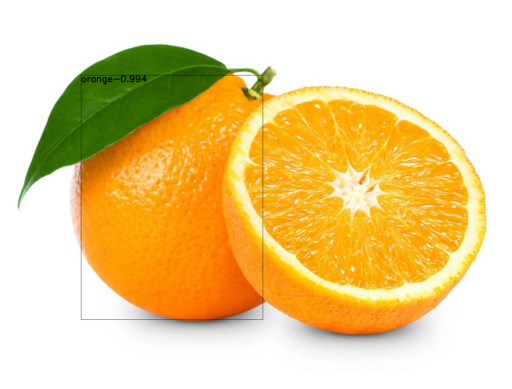

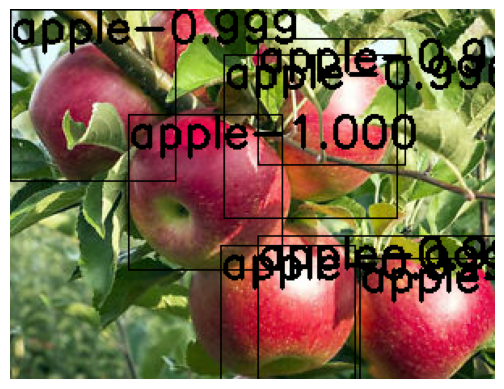

In [360]:
P = RegressionDataset.P
imgs_per_folder = 10
folders = [TEST_FOLDER]
for folder in folders:
    files = np.unique([file.split('.')[0] for file in os.listdir(folder)])
    rand_pathes = np.random.choice(files, size=imgs_per_folder, replace=False)
    for rand_path in rand_pathes:
        img = open_image(os.path.join(folder, rand_path + '.jpg'))
        ss.setBaseImage(img)
        ss.switchToSelectiveSearchFast()
        cur_bbs = ss.process()[:1000]
        cur_gts = parse_xml(os.path.join(folder, rand_path + '.xml'))
        final_bbs = []
        for cur_bb in cur_bbs:
            for cur_gt in cur_gts:
                val = iou(cur_bb, cur_gt)
                if val > 0.6:
                    bb_x1, bb_y1, bb_w, bb_h = \
                    max(cur_bb[0]-P, 0), max(cur_bb[1]-P, 0), cur_bb[2] + 2*P, cur_bb[3] + 2*P
                    mx_info = F.softmax(fe(
                        fe_trans(
                            Image.fromarray(img[bb_y1:bb_y1+bb_h, bb_x1:bb_x1+bb_w])
                        ).unsqueeze(0).to(device)), dim=-1
                    ).max(dim=-1)
                    final_bbs.append((cur_bb, mx_info))
        
        final_bbs = non_max_supression(*zip(*final_bbs))
        for i, (bbs, mx_info) in enumerate(final_bbs):
            x, y, w, h = bbs
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 0), 1)
            label = classes[mx_info.indices.item()]
            score = mx_info.values.item()
            cv2.putText(img, f"{label}-{score:.3f}", (x, y+20), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)        
        plt.imshow(img)
        plt.axis('off')
        plt.show()

In [363]:
torch.save(fe.state_dict(), "feature_extractor.pth")

In [365]:
torch.save(reg_fe.state_dict(), "bounding_box_regressor.pth")